In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv(r"C:\Users\Administrator\Downloads\expectation_decider_dataset.csv")

In [5]:
df.head()

,study_hours,attendance,group_discussion,previous_test_score,final_exam_pass
0,5,51,No,66,Fail
1,9,58,Yes,46,Fail
2,20,77,Yes,38,Pass
3,4,63,Yes,38,Fail
4,19,62,No,63,Pass


In [13]:
# 1. Understanding the Basics of Probability

#Probability is the measure of how likely an event is to occur.

#The value of probability ranges from 0 to 1.

### Key Probability Terminology

# **Experiment:** A process that produces an outcome.
# **Outcome:** The result of an experiment.
# **Event:** A specific outcome or group of outcomes.
# **Sample Space:** The set of all possible outcomes.
# **Joint Probability:** Probability that two events occur together.
# **Marginal Probability:** Probability of a single event.
# **Conditional Probability:** Probability of one event given that another event has occurred.

### Probability Events from the Dataset




In [15]:
#1. Probability that a student studies more than 10 hours and fails

In [16]:
a = len(df[(df["study_hours"] > 10) & (df["final_exam_pass"] == "Fail")])

b = len(df)

p = a / b

print("Probability:", p)

Probability: 0.025


In [17]:
#2. Probability of failing the exam

In [18]:
a = len(df[df["final_exam_pass"] == "Fail"])

b = len(df)

p = a / b

print("Probability:", p)

Probability: 0.265


In [19]:
#3. Probability of passing the exam

In [20]:
a = len(df[df["final_exam_pass"] == "Pass"])

b = len(df)

p = a / b

print("Probability:", p)

Probability: 0.735


In [21]:
## Types of Events

#1. Empirical probability

#Empirical probability is calculated from the actual observations in the dataset.

#Formula:

#P(Event) = Number of favorable outcomes / Total number of outcomes


In [22]:
# Taking a random sample of 100 students
sample = df.sample(100, random_state=42)

# Calculating probability of passing
a = len(sample[sample["final_exam_pass"] == "Pass"])

b = len(sample)

p = a / b

print("Empirical Probability of Passing:", p)

Empirical Probability of Passing: 0.76


In [23]:
# Theoretical probability is calculated using mathematical formulas or complete known data.
# It represents the expected probability of an event.
# Calculating probability of passing using full dataset
a = len(df[df["final_exam_pass"] == "Pass"])

b = len(df)

p = a / b

print("Theoretical Probability of Passing:", p)

Theoretical Probability of Passing: 0.735


In [25]:
## 3. Random Variable and Probability Distribution

#Let X be the number of students who pass the final exam out of 3 randomly selected students.

#Therefore, X can have the following values:

#X = 0, 1, 2, 3

#Where:

#X = 0 means no student passes.

#X = 1 means one student passes.

#X = 2 means two students pass.

#X = 3 means all three students pass.

In [26]:
p = df["final_exam_pass"].value_counts(normalize=True)["Pass"]
print("Probability of Pass:", p)

q = 1 - p
print("Probability of Fail:", q)

Probability of Pass: 0.735
Probability of Fail: 0.265


In [27]:
x = np.array([0, 1, 2, 3])

probabilities = np.array([
    q**3,
    3*p*(q**2),
    3*(p**2)*q,
    p**3
])

print("X:", x)
print("Probability Distribution:", probabilities)

X: [0 1 2 3]
Probability Distribution: [0.01860963 0.15484613 0.42947887 0.39706537]


In [28]:
distribution_table = pd.DataFrame({
    "X (Students Passing)": x,
    "P(X=x)": probabilities
})

print(distribution_table)

   X (Students Passing)    P(X=x)
0                     0  0.018610
1                     1  0.154846
2                     2  0.429479
3                     3  0.397065


In [29]:
mean = np.sum(x * probabilities)

print("Mean:", mean)

Mean: 2.205


In [30]:
variance = np.sum((x - mean)**2 * probabilities)

print("Variance:", variance)

Variance: 0.584325


In [8]:
## 4. Venn Diagram in Probability

#Event A = Students who study more than 10 hours per week.

#Event B = Students who attend more than 80% of classes.

#The overlapping area represents students who satisfy both conditions.

#The number of students in each group is calculated from the dataset.

### Result

#The Venn diagram shows the students who study more than 10 hours, students who attend more than 80% of classes, and the students who satisfy both conditions..

In [9]:
!pip install matplotlib-venn

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for matplotlib-venn: filename=matplotlib_venn-1.1.2-py3-none-any.whl size=45440 sha256=e17333c18fcda37ac8f9496e0a15beab94050e4d027fe1705705650e610c232d
  Stored in directory: c:\users\administrator\appdata\local\pip\cache\wheels\d1\5f\e6\771479559f992b8398265ebf61f8a3d33ca0b8f75552e06ad2
Successfully built matplotlib-venn


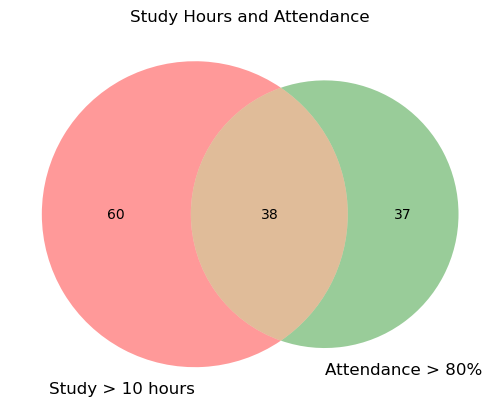

In [10]:
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Students who study more than 10 hours
ta = len(df[df["study_hours"] > 10])

# Students who have more than 80% attendance
tb = len(df[df["attendance"] > 80])

# Students who study more than 10 hours AND have more than 80% attendance
c = len(df[(df["study_hours"] > 10) & (df["attendance"] > 80)])

# Study more than 10 hours only
a = ta - c

# Attendance more than 80% only
b = tb - c

# Create Venn diagram
venn2(
    subsets=(a, b, c),
    set_labels=("Study > 10 hours", "Attendance > 80%")
)

plt.title("Study Hours and Attendance")
plt.show()

In [11]:

## Contingency table & Probability Calculation


In [12]:
Contingency_table = pd.crosstab(df["group_discussion"],
                                df["final_exam_pass"],margins=True)
Contingency_table

final_exam_pass,Fail,Pass,All
group_discussion,,,
No,36,71,107
Yes,17,76,93
All,53,147,200


In [14]:
## Joint Probability

#Group Discussion = Yes AND Pass

In [15]:
Contingency_probability = pd.crosstab(df["group_discussion"],
                                      df["final_exam_pass"],margins=True,normalize="all")
Contingency_probability

final_exam_pass,Fail,Pass,All
group_discussion,,,
No,0.180,0.355,0.535
Yes,0.085,0.380,0.465
All,0.265,0.735,1.000


In [16]:
# Marginal Probability
#Pass

In [17]:
p=len(df[df["final_exam_pass"]=="Pass"])/len(df)
print("Probability:",p)

Probability: 0.735


In [18]:
# Conditional Probability

In [19]:
# Formula:
# P(Pass | Group Discussion) = P(Pass AND Group Discussion) / P(Group Discussion)

yes_students = len(df[df["group_discussion"] == "Yes"])

yes_and_pass = len(
    df[
        (df["group_discussion"] == "Yes") &
        (df["final_exam_pass"] == "Pass")
    ])

conditional_probability = yes_and_pass / yes_students

print("Number of students with group discussion:", yes_students)
print("Students with group discussion and Pass:", yes_and_pass)
print("Probability of passing given group discussion:", conditional_probability)
print("Percentage:", conditional_probability * 100, "%")

Number of students with group discussion: 93
Students with group discussion and Pass: 76
Probability of passing given group discussion: 0.8172043010752689
Percentage: 81.72043010752688 %


In [20]:
# 6. Understanding Relationships
### Conditional Probability Interpretation
#Conditional probability tells us the probability of one event happening when we already know that another event has happened.

#In this project, P(Pass | Group Discussion = Yes) tells us the probability that a student passes the exam among students who participated in group discussions.

### Independent or Dependent?
#Two events are independent when the occurrence of one event does not affect the probability of the other event.

#We compare:

#P(Pass | Group Discussion = Yes)

#with

#P(Pass)

#If the values are different, it suggests that the two events are dependent.

### Mutually Exclusive?
#The events are not mutually exclusive because a student can participate in group discussion and also pass the exam.

In [21]:
pass_probability = len(
    df[df["final_exam_pass"] == "Pass"]
) / len(df)

print("P(Pass):", pass_probability*100,"%")
print("P(Pass | Group Discussion = Yes):", conditional_probability*100,"%")

P(Pass): 73.5 %
P(Pass | Group Discussion = Yes): 81.72043010752688 %


In [22]:
# 7. Bayes Theorem

#Given:

#P(High Attendance | Pass) = 0.45

#P(High Attendance | Fail) = 0.17

#P(High Attendance) = 0.375

#We need to find:

#P(Pass | High Attendance)

In [23]:
P_high_given_pass = 0.45
P_high_given_fail = 0.17
P_high = 0.375

P_pass = (P_high - P_high_given_fail) / (P_high_given_pass - P_high_given_fail)

P_fail = 1 - P_pass

P_pass_given_high = (P_high_given_pass * P_pass) / P_high

print("P(Pass):", P_pass)
print("P(Fail):", P_fail)
print("P(Pass | High Attendance):", P_pass_given_high)

P(Pass): 0.732142857142857
P(Fail): 0.267857142857143
P(Pass | High Attendance): 0.8785714285714284


In [24]:
### Final Summary

#In this project, I used Python, Pandas, and NumPy to analyze the student dataset. First, I calculated basic probabilities like the probability of passing and failing the exam. Then I calculated empirical and theoretical probabilities.

#For the random variable, I considered the number of students passing out of 3 selected students and created its probability distribution. I also calculated the mean and variance.

#I created a Venn diagram to compare students studying more than 10 hours with students having more than 80% attendance. After that, I created a contingency table for group discussion and exam results and calculated joint, marginal, and conditional probabilities.

#Finally, I compared the probabilities to understand the relationship between group discussion and passing, and applied Bayes’ Theorem to calculate the probability of passing given high attendance.